# Supplementary figures

Fig 1 : AIC / BIC

In [4]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
from sklearn.mixture import GaussianMixture
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap  

In [5]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


 Get embeddings that are to be clustered

In [3]:
# fit UMAP to partial fn data
df_fn_comm_par= reader.data_read_bz2('results/comm_umap_results/pca_part_df_fn')
df_fn_comm_full=reader.data_read_bz2('results/comm_umap_results/pca_full_df_fn')
umap_model = umap.UMAP(n_neighbors=5,n_components=2,random_state=42)
# removing NaN if any 
df_fn_comm_par.dropna(inplace=True)

# comment out after finalised
df_combined= pd.concat([df_fn_comm_full,df_fn_comm_par],axis = 0)

_reducer = umap_model.fit(df_fn_comm_par.values)

# transforming using reducer
embedding_full = _reducer.transform(df_fn_comm_full.values)
embedding_part = _reducer.transform(df_fn_comm_par.values)
whole_embedding = np.concatenate((embedding_full, embedding_part), axis=0)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Let's test for optimum number of clusters

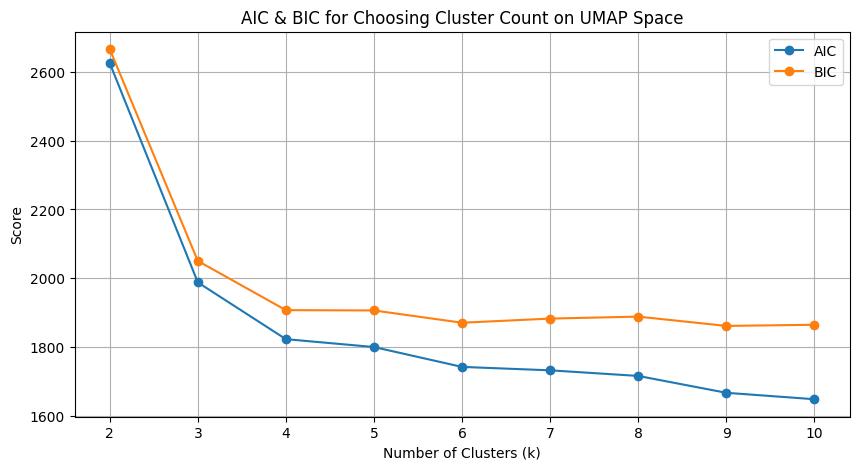

In [7]:
umap_embedding = whole_embedding
# 2. Setup range of clusters to test
n_components_range = range(2, 11)
aic_scores = []
bic_scores = []

for n_components in n_components_range:
    # Fit GMM on the UMAP embeddings
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(umap_embedding)
    
    # 3. Save the scores
    aic_scores.append(gmm.aic(umap_embedding))
    bic_scores.append(gmm.bic(umap_embedding))

# 4. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(n_components_range, aic_scores, label='AIC', marker='o')
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.title('AIC & BIC for Choosing Cluster Count on UMAP Space')
plt.legend()
plt.grid(True)
plt.show()